In [ ]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from epspkit.io import load_bulk
from epspkit.preprocess import preprocess
from epspkit.template import match_feature
from epspkit.plotting import plot_trace, plot_io_curve, plot_fit, plot_detected
from epspkit.base import RecordingResult, PreprocessParams
# from epspkit.snr import snr_detect
from epspkit.analysis import pop_spike_threshold
import matplotlib.pyplot as plt

In [ ]:
base_path = r"C:\Users\bbyer\OneDrive\Documents\UniversityofKentucky\BachstetterLab\epsp-kit\epsp-kit\src\data"

# 29 mice, 37 ca1 slices, 34 dg slices
# 9 ca1 template slices, 6 dg template slices. So 28 test slices each

all_files_ca1 = ['2025_05_22_0006.abf', '2025_05_22_0004.abf', '2025_05_22_0000.abf', '2025_03_07_0004.abf', '2025_03_07_0008.abf', '2025_03_07_0006.abf', '2025_03_07_0002.abf', '2025_03_07_0000.abf', '2025_03_06_0002.abf', '2025_03_06_0004.abf', '2025_03_06_0010.abf', '2025_03_06_0000.abf', '2025_03_06_0006.abf', '2025_03_06_0008.abf', '2025_03_06_0011.abf', '2025_03_05_0006.abf', '2025_03_05_0004.abf', '2025_03_05_0008.abf', '2025_03_05_0002.abf', '2025_03_05_0000.abf', '2025_03_04_0007.abf', '2025_03_04_0000.abf', '2025_03_04_0002.abf', '2025_03_04_0004.abf', '2025_03_04_0006.abf', '2025_03_04_0010.abf', '2025_03_04_0012.abf', '2025_03_03_0005.abf', '2025_03_03_0000.abf', '2025_03_03_0002.abf', '2025_03_03_0003.abf', '2025_03_03_0009.abf', '2025_03_03_0007.abf', '2025_03_02_0006.abf', '2025_03_02_0009.abf', '2025_03_02_0002.abf', '2025_03_02_0000.abf']

mouse_id_ca1 = ['ephys-1-144-04', 'ephys-1-144-03', 'ephys-1-144-01', 'ephys-1-85-07', 'ephys-1-85-09', 'ephys-1-85-08', 'ephys-1-85-06', 'ephys-1-85-06', 'ephys-1-85-01', 'ephys-1-85-02', 'ephys-1-85-03', 'ephys-1-85-01', 'ephys-1-85-02', 'ephys-1-85-03', 'ephys-1-85-04', 'ephys-1-90-09', 'ephys-1-90-08', 'ephys-1-90-10', 'ephys-1-90-07', 'ephys-1-90-06', 'ephys-1-90-03', 'ephys-1-90-01', 'ephys-1-90-01', 'ephys-1-90-02', 'ephys-1-90-02', 'ephys-1-90-04', 'ephys-1-90-05', 'ephys-1-75-08', 'ephys-1-75-06', 'ephys-1-75-06', 'ephys-1-75-07', 'ephys-1-75-10', 'ephys-1-75-09', 'ephys-1-75-03', 'ephys-1-75-05', 'ephys-1-75-01', 'ephys-1-75-01']

all_files_dg = ['2025_05_22_0007.abf', '2025_05_22_0001.abf', '2025_05_22_0005.abf', '2025_03_07_0009.abf', '2025_03_07_0007.abf', '2025_03_07_0005.abf', '2025_03_07_0003.abf', '2025_03_06_0003.abf', '2025_03_06_0001.abf', '2025_03_06_0005.abf', '2025_03_06_0012.abf', '2025_03_06_0007.abf', '2025_03_06_0009.abf', '2025_03_05_0005.abf', '2025_03_05_0007.abf', '2025_03_05_0009.abf', '2025_03_05_0003.abf', '2025_03_05_0001.abf', '2025_03_04_0001.abf', '2025_03_04_0003.abf', '2025_03_04_0005.abf', '2025_03_04_0008.abf', '2025_03_04_0009.abf', '2025_03_04_0011.abf', '2025_03_04_0013.abf', '2025_03_03_0001.abf', '2025_03_03_0004.abf', '2025_03_03_0006.abf', '2025_03_03_0008.abf', '2025_03_03_0010.abf', '2025_03_02_0003.abf', '2025_03_02_0010.abf', '2025_03_02_0001.abf', '2025_03_02_0007.abf']

mouse_id_dg = ['ephys-1-144-04', 'ephys-1-144-01', 'ephys-1-144-03', 'ephys-1-85-09', 'ephys-1-85-08', 'ephys-1-85-07', 'ephys-1-85-06', 'ephys-1-85-01', 'ephys-1-85-01', 'ephys-1-85-02', 'ephys-1-85-04', 'ephys-1-85-02', 'ephys-1-85-03', 'ephys-1-90-08', 'ephys-1-90-09', 'ephys-1-90-10', 'ephys-1-90-07', 'ephys-1-90-06', 'ephys-1-90-01', 'ephys-1-90-01', 'ephys-1-90-02', 'ephys-1-90-03', 'ephys-1-90-03', 'ephys-1-90-04', 'ephys-1-90-05', 'ephys-1-75-06', 'ephys-1-75-07', 'ephys-1-75-08', 'ephys-1-75-09', 'ephys-1-75-10', 'ephys-1-75-01', 'ephys-1-75-05', 'ephys-1-75-01', 'ephys-1-75-03']

template_files_ca1 = ['2025_03_04_0002.abf','2025_03_05_0004.abf', '2025_03_06_0010.abf', '2025_03_02_0000.abf', '2025_03_07_0002.abf', '2025_03_06_0004.abf', '2025_03_05_0000.abf', '2025_03_04_0012.abf', '2025_03_03_0007.abf']
template_files_dg = ['2025_05_22_0005.abf', '2025_03_06_0001.abf','2025_03_05_0007.abf','2025_03_04_0005.abf','2025_03_04_0003.abf','2025_03_05_0009.abf']

# 1. Extract the file prefix (e.g., '2025_03_06_0002') to use as the unique ID
ca1_map = {f: f.split('.')[0] for f in all_files_ca1}
dg_map = {f: f.split('.')[0] for f in all_files_dg}

# 2. Filter out the template files to get your test files
ca1_test_files = [f for f in all_files_ca1 if f not in template_files_ca1]
dg_test_files = [f for f in all_files_dg if f not in template_files_dg]

# 3. Look up the now-unique file prefix IDs
ca1_test_ids = [ca1_map[f] for f in ca1_test_files]
dg_test_ids = [dg_map[f] for f in dg_test_files]
ca1_train_ids = [ca1_map[f] for f in template_files_ca1]
dg_train_ids = [dg_map[f] for f in template_files_dg]

# 4. Join paths
template_files_ca1_full = [os.path.join(base_path, f) for f in template_files_ca1]
template_files_dg_full = [os.path.join(base_path, f) for f in template_files_dg]
ca1_test_files_full = [os.path.join(base_path, f) for f in ca1_test_files]
dg_test_files_full = [os.path.join(base_path, f) for f in dg_test_files]

intensities_list = [25, 50, 75, 100, 150, 200, 250, 300, 400, 500, 600]
#template_ints = [200, 250, 300, 400, 500, 600]
template_ints = [300, 400, 500, 600]


In [ ]:
# -------------------------------------------------------------
# CA1 Pipeline
# -------------------------------------------------------------
params = PreprocessParams(
    baseline_window=(0, 0.1),
    artifact_window=(0, 2.25),
    artifact="template",
    smoothing="savgol",
    smoothing_params={
        "size": 7,
        "window_length": 15,
        "polyorder": 3,
        "cutoff": 2000.0,
        "order": 3,
    },
)

unsmooth_params = PreprocessParams(
    baseline_window=(0, 0.1),
    artifact_window=(0, 2.25),
    artifact="template",
    smoothing="none",
    smoothing_params={
        "size": 7,
        "window_length": 15,
        "polyorder": 3,
        "cutoff": 2000.0,
        "order": 3,
    },
)
print("Processing CA1...")
ca1_raw_train = load_bulk(template_files_ca1_full, intensities=intensities_list, id_values=ca1_train_ids, repnum=3)
ca1_raw_test = load_bulk(ca1_test_files_full, intensities=intensities_list, id_values=ca1_test_ids, repnum=3)

ca1_prep_train = preprocess(ca1_raw_train, params.baseline_window, params.artifact_window, params.artifact, params.smoothing, params.smoothing_params)
ca1_prep_test = preprocess(ca1_raw_test, params.baseline_window, params.artifact_window, params.artifact, params.smoothing, params.smoothing_params)
ca1_test_unsmoothed = preprocess(ca1_raw_test, unsmooth_params.baseline_window, unsmooth_params.artifact_window, unsmooth_params.artifact, unsmooth_params.smoothing, smoothing_params=unsmooth_params.smoothing_params)

ca1_results = RecordingResult(preprocess_params=params)

ca1_results.add("Fiber Volley", match_feature(
    train_df=ca1_prep_train, test_df=ca1_prep_test, 
    template_window=(1.5, 3.0), search_window=(1.0, 3.2), 
    template_intensities=template_ints, 
    r2_threshold=0.8,
    slope_transform=False
))

ca1_results.add("fEPSP", match_feature(
    train_df=ca1_prep_train, test_df=ca1_prep_test, 
    template_window=(2.7, 4.0), search_window=(2.5, 5.0), 
    template_intensities=template_ints, 
    r2_threshold=0.4,
    slope_transform=True
))

ca1_results.add("Population Spike", match_feature(
    train_df=ca1_prep_train, test_df=ca1_prep_test, 
    template_window=(4.5, 6.0), search_window=(4.0, 6.5), 
    template_intensities=[500,600], 
    r2_threshold=0.8,
    slope_transform=False
))

# ca1_pop_spike_data = ca1_results.results["fEPSP"].result[["id", "intensity", "scale"]].merge(
#     ca1_results.results["Population Spike"].result[["id", "intensity", "detected"]],
#     on=["id", "intensity"],
# ).dropna(subset=["scale"])
# ca1_ps_threshold = pop_spike_threshold(
#     ca1_pop_spike_data["detected"].to_numpy(),
#     ca1_pop_spike_data["scale"].to_numpy(),
# )
# print(f"CA1 pop_spike_threshold: {ca1_ps_threshold}")

print("Plotting CA1 Responses...")
ca1_trace_fig, ca1_trace_ax = plot_trace(ca1_prep_test, recording_result=ca1_results, id_value=ca1_test_ids[6], features=["Fiber Volley", "fEPSP", "Population Spike"], intensities=intensities_list, annotated=True)
ca1_io_fig, ca1_io_axes = plot_io_curve(ca1_results, features=["Fiber Volley", "fEPSP", "Population Spike"], intensities=intensities_list)
ca1_fit_fig, ca1_fit_axes = plot_fit(ca1_prep_test, ca1_results, features=["Fiber Volley", "fEPSP", "Population Spike"], intensity=50, id_value=ca1_test_ids[0])
ca1_io_fig.suptitle("IO Curves - CA1")

ca1_io_fig.show()
# ca1_io_fig.set_size_inches()


#display(ca1_results.results.get("Population Spike").result)


Processing CA1...
Plotting CA1 Responses...


Text(0.5, 0.98, 'IO Curves - CA1')

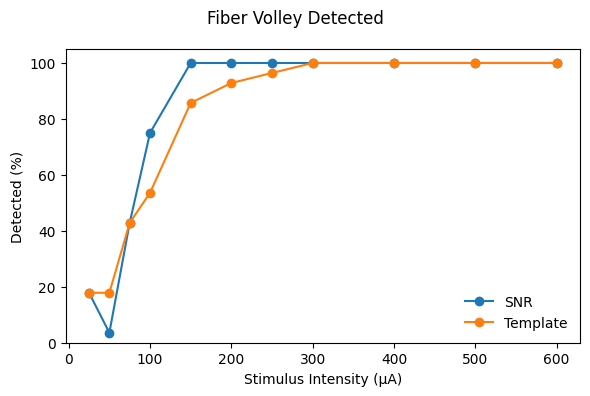

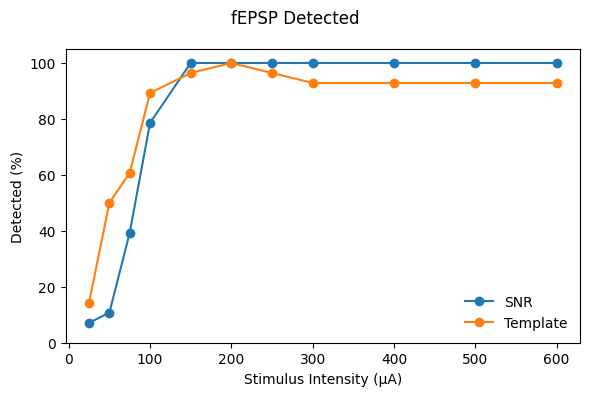

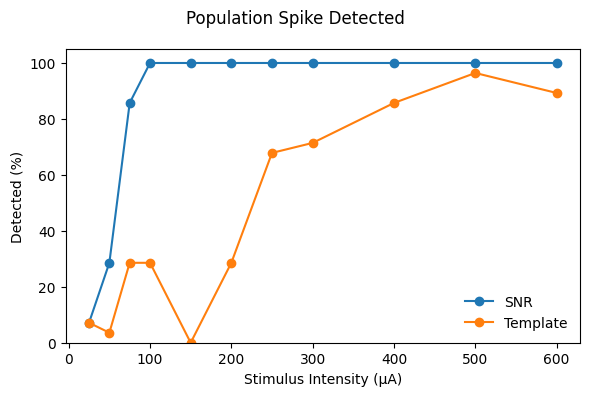

In [ ]:
# -------------------------------------------------------------
# CA1 SNR Mini Test
# -------------------------------------------------------------

ca1_snr_results = RecordingResult(
    preprocess_params=unsmooth_params
)

ca1_snr_results.add("Fiber Volley", snr_detect(
    test_df=ca1_test_unsmoothed,
    search_window=(1.5, 3.0),
    noise_window=(23.5, 25.0),
    snr_threshold=3.5,
    polarity="negative",
    slope_transform=False,
))

ca1_snr_results.add("fEPSP", snr_detect(
    test_df=ca1_test_unsmoothed,
    search_window=(2.5, 5.0),
    noise_window=(23.5, 25.0),
    snr_threshold=3.5,
    polarity="negative",
    slope_transform=True,
))

ca1_snr_results.add("Population Spike", snr_detect(
    test_df=ca1_test_unsmoothed,
    search_window=(4.5, 6.0),
    noise_window=(23.5, 25.0),
    snr_threshold=3.5,
    polarity="positive",
    slope_transform=False,
))

# plot_trace(ca1_test_unsmoothed, recording_result=ca1_snr_results, id_value=ca1_test_ids[6], features=["fEPSP"], intensities=intensities_list, annotated=True)
plot_detected(fit_result=ca1_results, snr_result=ca1_snr_results, feature="Fiber Volley")
plot_detected(fit_result=ca1_results, snr_result=ca1_snr_results, feature="fEPSP")
plot_detected(fit_result=ca1_results, snr_result=ca1_snr_results, feature="Population Spike")

In [ ]:
# -------------------------------------------------------------
# DG Pipeline
# -------------------------------------------------------------
print("Processing DG...")
dg_raw_train = load_bulk(template_files_dg_full, intensities=intensities_list, id_values=dg_train_ids, repnum=3)
dg_raw_test = load_bulk(dg_test_files_full, intensities=intensities_list, id_values=dg_test_ids, repnum=3)

dg_prep_train = preprocess(dg_raw_train, params.baseline_window, (0,2.25), params.artifact, params.smoothing, params.smoothing_params)
dg_prep_test = preprocess(dg_raw_test, params.baseline_window, (0,2.25), params.artifact, params.smoothing, params.smoothing_params)

dg_results = RecordingResult(preprocess_params=params)

dg_results.add("Fiber Volley", match_feature(
    train_df=dg_prep_train, test_df=dg_prep_test, 
    template_window=(1.8, 2.5), search_window=(1.5, 3.2), 
    template_intensities=template_ints, r2_threshold=0.8, slope_transform=False
))

dg_results.add("fEPSP", match_feature(
    train_df=dg_prep_train, test_df=dg_prep_test, 
    template_window=(2.5, 3.6), search_window=(2.0, 5.0), 
    template_intensities=template_ints, r2_threshold=0.4, slope_transform=True
))

dg_results.add("Population Spike", match_feature(
    train_df=dg_prep_train, test_df=dg_prep_test, 
    template_window=(4.3, 5.7), search_window=(3.6, 6.5), 
    template_intensities=[500,600], 
    r2_threshold=0.8,
    slope_transform=False
))

Processing DG...


In [ ]:
# -------------------------------------------------------------
# Visualizations
# -------------------------------------------------------------


print("Plotting DG Responses...")
dg_trace_fig, dg_trace_ax = plot_trace(dg_prep_test, recording_result=dg_results, id_value=dg_test_ids[6], features=["Fiber Volley", "fEPSP", "Population Spike"], intensities=[200, 250, 300, 400, 500, 600], annotated=True)
dg_io_fig, dg_io_axes = plot_io_curve(dg_results, features=["Fiber Volley", "fEPSP", "Population Spike"], intensities=intensities_list)
dg_io_fig.suptitle("IO Curves - DG")
fig, ax = plot_detected(dg_results, "Population Spike")
fig1,ax1=plot_fit(dg_prep_test, dg_results, features=["Fiber Volley", "fEPSP", "Population Spike"], intensity=600, id_value=dg_test_ids[6])

Plotting DG Responses...
